In [4]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
image_folder = "Images"
annotation_folder = "Annotations"

In [ ]:
def preprocess(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (9, 9), 0)  
    _, th = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    th = cv2.bitwise_not(th)
    kernel = np.ones((9, 9), np.uint8)  
    close = cv2.morphologyEx(th, cv2.MORPH_CLOSE, kernel)
    return close

In [ ]:
def detect_dice(binary):
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary)
    dice_boxes = []
    
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area < 1000 or area > 30000:  
            continue
            
        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]
        
        ratio = w / float(h)
        if ratio < 0.5 or ratio > 1.5:  
            continue
            
        dice_boxes.append((x, y, w, h))
    
    return sorted(dice_boxes, key=lambda b: (b[1], b[0]))

In [ ]:
def detect_dots(roi):
    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (11, 11), 2)  
    
    h, w = gray.shape
    circles = cv2.HoughCircles(
        blur,
        cv2.HOUGH_GRADIENT,
        dp=1.2,
        minDist=min(h, w) / 3,  
        param1=65,  
        param2=20,  
        minRadius=int(min(h, w) * 0.08),
        maxRadius=int(min(h, w) * 0.20)
    )
    
    return min(len(circles[0]), 6) if circles is not None else 0

In [ ]:
def process_image(path):
    img = cv2.imread(path)
    binary = preprocess(img)
    dice_boxes = detect_dice(binary)
    
    values = []
    for (x, y, w, h) in dice_boxes:
        margin = int(0.10 * min(w, h))  
        roi = img[y + margin:y + h - margin, x + margin:x + w - margin]
        
        dots = detect_dots(roi)
        values.append(dots)
        
        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(
            img,
            str(dots),
            (x, y - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 0, 255),
            2
        )
    
    
    values = [min(v, 6) for v in values]
    
   
    valid_dice = [v for v in values if v >= 1]
    
    return img, len(valid_dice), valid_dice


def read_annotation(file):
    with open(file) as f:
        lines = f.readlines()
    
    real_faces = []
    for line in lines:
        parts = line.strip().split()
        face = int(parts[0])
        real_faces.append(face)
    
    real_dice = len(real_faces)
    return real_dice, real_faces


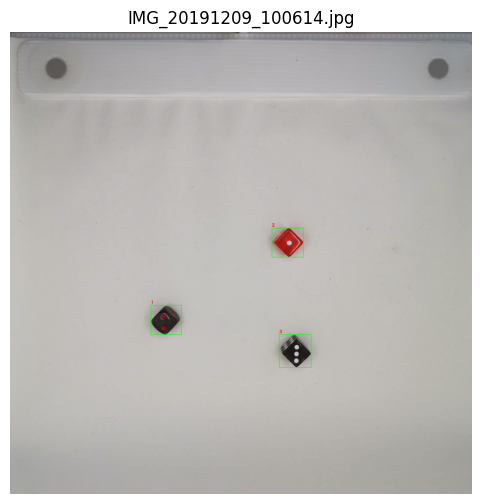

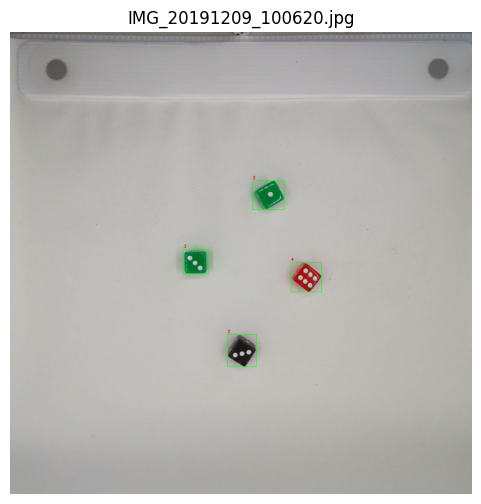

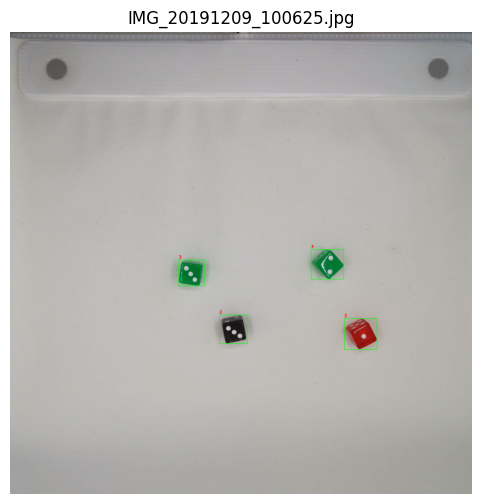

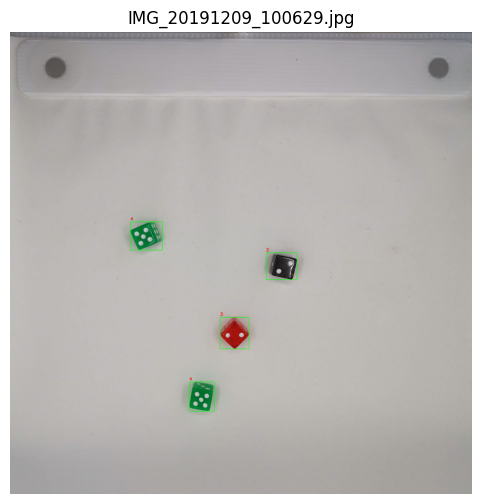

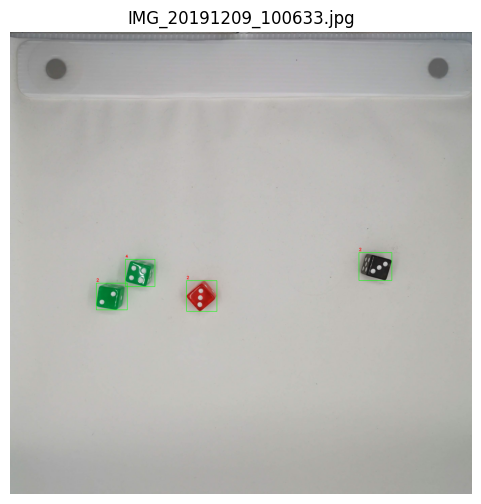

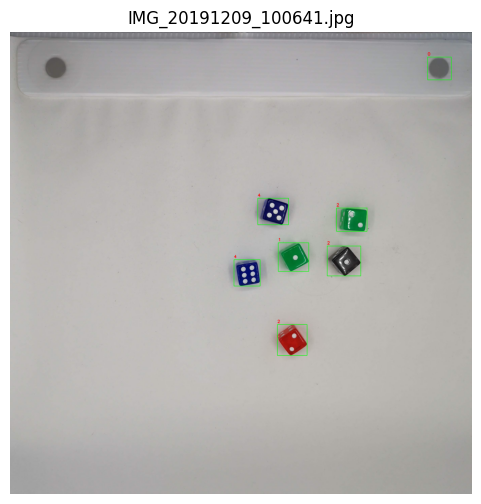

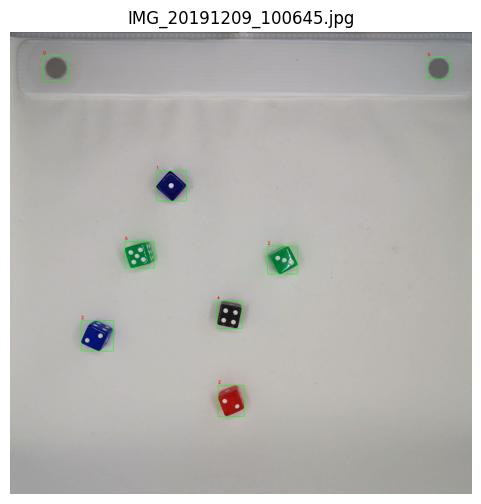

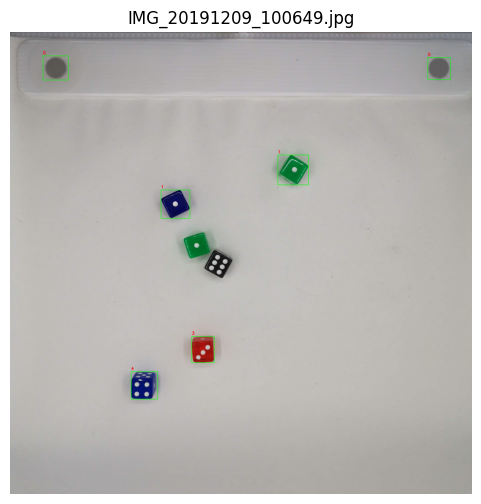

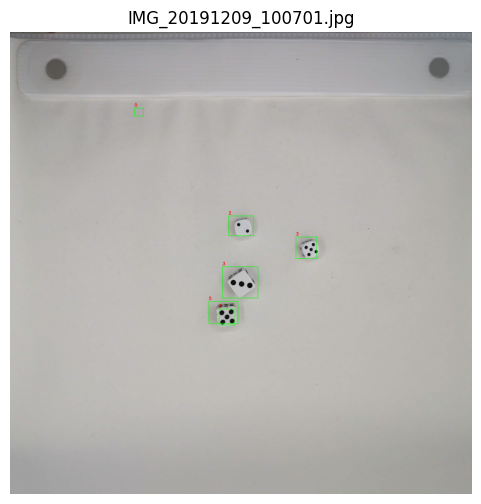

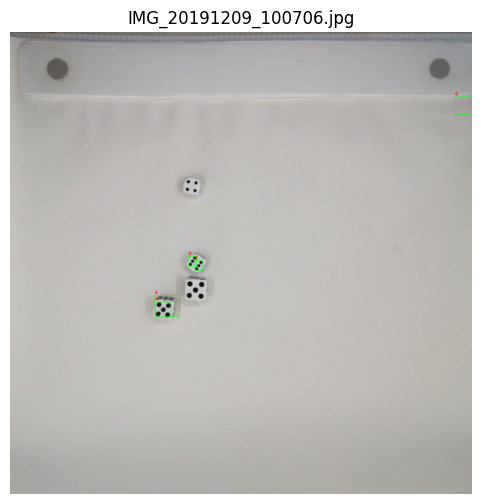

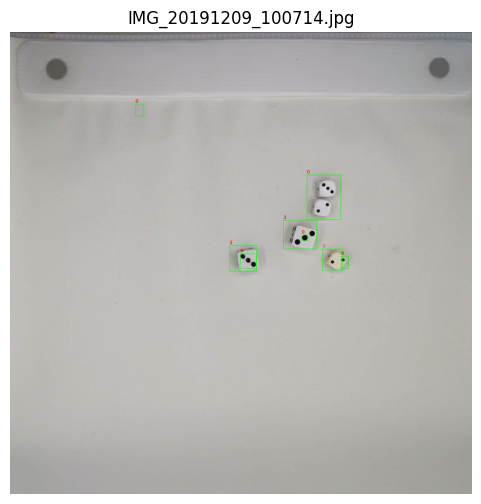

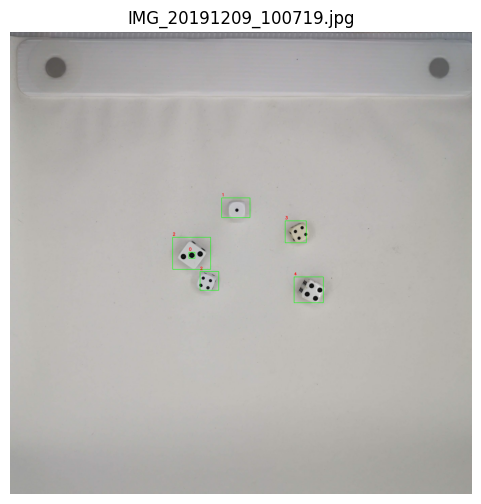

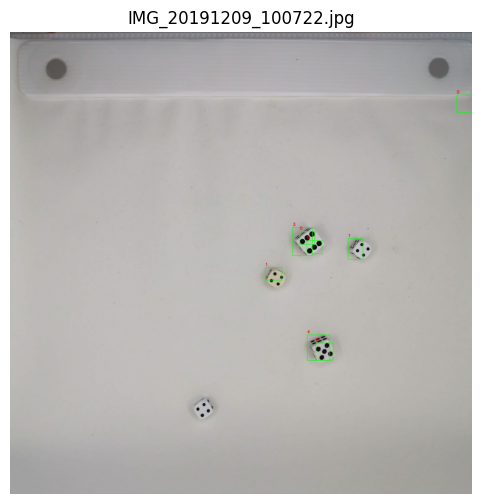

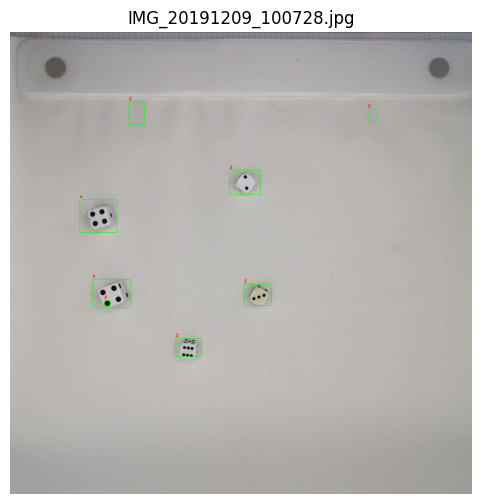

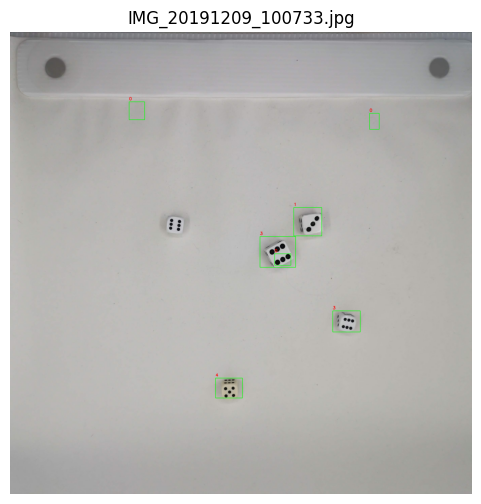

In [63]:
results = []

for file in os.listdir(image_folder):
    path = os.path.join(image_folder, file)
    img_out, dice_count, values = process_image(path)
    
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(img_out, cv2.COLOR_BGR2RGB))
    plt.title(file)
    plt.axis("off")
    plt.show()
    
    results.append({
        "image": file,
        "detected_dice": dice_count,
        "detected_faces": values
    })

In [64]:
def read_annotation(file):

    with open(file) as f:
        lines = f.readlines()

    dice = int(lines[0].split(":")[1])
    faces = list(map(int,lines[1].split(":")[1].split(",")))

    return dice, faces

In [65]:
table = []

def read_annotation(file):

    with open(file) as f:
        lines = f.readlines()

    real_faces = []
    
    for line in lines:
        parts = line.strip().split()
        face = int(parts[0])
        real_faces.append(face)

    real_dice = len(real_faces)

    return real_dice, real_faces


for r in results:

    name = r["image"]

    base_name = os.path.splitext(name)[0]
    ann_file = os.path.join(annotation_folder, base_name + ".txt")

    real_dice, real_faces = read_annotation(ann_file)

    table.append([
        name,
        r["detected_dice"],
        real_dice,
        r["detected_faces"],
        real_faces
    ])


df = pd.DataFrame(table, columns=[
    "Imagen",
    "Dados Detectados",
    "Dados Reales",
    "Caras Detectadas",
    "Caras Reales"
])

df

,Imagen,Dados Detectados,Dados Reales,Caras Detectadas,Caras Reales
0,IMG_20191209_100614.jpg,3,3,"[2, 1, 3]","[1, 0, 2]"
1,IMG_20191209_100620.jpg,4,4,"[2, 3, 4, 2]","[0, 2, 2, 5]"
2,IMG_20191209_100625.jpg,4,4,"[4, 3, 2, 2]","[0, 1, 2, 2]"
3,IMG_20191209_100629.jpg,4,4,"[4, 2, 3, 4]","[1, 1, 4, 4]"
4,IMG_20191209_100633.jpg,4,4,"[2, 4, 2, 2]","[1, 2, 2, 3]"
5,IMG_20191209_100641.jpg,6,6,"[4, 2, 1, 2, 4, 2]","[0, 0, 1, 1, 4, 5]"
6,IMG_20191209_100645.jpg,6,6,"[1, 5, 2, 4, 2, 2]","[0, 1, 1, 2, 3, 4]"
7,IMG_20191209_100649.jpg,4,6,"[1, 1, 3, 4]","[0, 0, 0, 2, 3, 5]"
8,IMG_20191209_100701.jpg,5,4,"[2, 3, 3, 5, 5]","[1, 4, 4, 2]"
9,IMG_20191209_100706.jpg,2,4,"[4, 4]","[3, 5, 4, 4]"


In [ ]:
dice_error = []
face_error = []

for r, row in zip(results, table):
    
    
    dice_error.append(abs(row[1] - row[2]))
    
     
    det = sorted(r["detected_faces"])
    real = sorted(row[4])
    
    min_len = min(len(det), len(real))
    
    error = 0
    for i in range(min_len):
        error += abs(det[i] - real[i])
    
    
    error += abs(len(det) - len(real)) * 6
    
    face_error.append(error)


mean_dice_error = np.mean(dice_error) if dice_error else 0
mean_face_error = np.mean(face_error) if face_error else 0

print("Error medio dados:", mean_dice_error)
print("Error medio caras:", mean_face_error)

Error medio dados: 0.4666666666666667
Error medio caras: 6.866666666666666
